**Setup toàn bộ môi trường + dataset + code**

In [ ]:
# =========================================================
# CELL 1 - FULL SETUP COLAB
# =========================================================
# ===== ĐI VỀ /content =====
%cd /content
# ===== CHECK GPU =====
import torch

print("=" * 50)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("=" * 50)

# =========================================================
# CLONE GITHUB
# =========================================================

!git clone -b prompt-guided https://github.com/ThongLuc2k3/Prompt-Guided-XRay-Segmentation.git

# =========================================================
# DOWNLOAD DATASET ZIP TỪ GOOGLE DRIVE
# =========================================================

!gdown --id 1MZIZx7XygG_T_UKiU0H8f_5zWZCgJIUz

# =========================================================
# UNZIP DATASET
# =========================================================

!unzip -q dataset_BTXRD.zip

# =========================================================
# KIỂM TRA DATASET
# =========================================================

print("\nDATASET STRUCTURE:")
!ls dataset_BTXRD

# =========================================================
# COPY DATASET VÀO PROJECT
# =========================================================

!mv dataset_BTXRD Prompt-Guided-XRay-Segmentation/

# =========================================================
# ĐI VÀO PROJECT
# =========================================================

%cd Prompt-Guided-XRay-Segmentation

# =========================================================
# INSTALL REQUIREMENTS
# =========================================================

!pip install -q tqdm opencv-python matplotlib scikit-image gdown

print("\nSETUP DONE!")

/content
CUDA: True
GPU: Tesla T4
Cloning into 'Prompt-Guided-XRay-Segmentation'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 39 (delta 13), reused 32 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 24.91 KiB | 8.30 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1MZIZx7XygG_T_UKiU0H8f_5zWZCgJIUz
From (redirected): https://drive.google.com/uc?id=1MZIZx7XygG_T_UKiU0H8f_5zWZCgJIUz&confirm=t&uuid=def1a9fb-36b4-4423-a6fa-8b260532e854
To: /content/dataset_BTXRD.zip
100% 3.19G/3.19G [00:30<00:00, 103MB/s]

DATASET STRUCTURE:
test  train  val
/content/Prompt-Guided-XRay-Segmentation

SETU

**Train**

In [ ]:
# =========================================================
# TRAIN
# =========================================================

!python train.py

🚀 KHỞI ĐỘNG HUẤN LUYỆN BASELINE - THIẾT BỊ: cuda
Batch Size: 4 | Epochs: 50 | LR: 0.0001
Epoch 1/50 [Train]: 100% 374/374 [04:57<00:00,  1.26it/s, loss=1.02]
🥇 [BEST] Epoch 1 | Train Loss: 1.4302 | Val Loss: 1.2480 | Dice: 0.6641 | IoU: 0.5380 | Pre: 0.5652 | Rec: 0.8448
Epoch 2/50 [Train]: 100% 374/374 [04:55<00:00,  1.26it/s, loss=0.933]
🥇 [BEST] Epoch 2 | Train Loss: 1.1788 | Val Loss: 1.1474 | Dice: 0.6832 | IoU: 0.5586 | Pre: 0.5937 | Rec: 0.8516
Epoch 3/50 [Train]: 100% 374/374 [04:53<00:00,  1.27it/s, loss=1.17]
🥇 [BEST] Epoch 3 | Train Loss: 1.0854 | Val Loss: 1.0330 | Dice: 0.7348 | IoU: 0.6154 | Pre: 0.6761 | Rec: 0.8500
Epoch 4/50 [Train]: 100% 374/374 [04:51<00:00,  1.28it/s, loss=1.09]
🥇 [BEST] Epoch 4 | Train Loss: 1.0044 | Val Loss: 0.9504 | Dice: 0.7549 | IoU: 0.6372 | Pre: 0.6822 | Rec: 0.8753
Epoch 5/50 [Train]: 100% 374/374 [04:55<00:00,  1.27it/s, loss=0.575]
🥇 [BEST] Epoch 5 | Train Loss: 0.9311 | Val Loss: 0.8794 | Dice: 0.7806 | IoU: 0.6640 | Pre: 0.6991 | Rec: 0

**Test + Dice + IoU + BCE**

Unet_2D

In [ ]:
# @title
# =========================================================
# TEST PHASE (CLEAN - PAPER VERSION)
# =========================================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
import torch.nn as nn

from dataset import BTXRD_Dataset
from models.networks.unet_2D import unet_2D

# =========================================================
# CONFIG
# =========================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "checkpoints/att_unet_best.pth"

# =========================================================
# LOAD MODEL
# =========================================================

model = unet_2D(in_channels=1, n_classes=1).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

# =========================================================
# DATASET
# =========================================================

test_dataset = BTXRD_Dataset(
    image_dir="dataset_BTXRD/test/images",
    mask_dir="dataset_BTXRD/test/masks",
    img_size=512,
    is_train=False
)

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# =========================================================
# VISUALIZATION CONTROL
# =========================================================
# 👉 đổi index ở đây để xem ảnh bạn muốn
SHOW_INDEX = [0, 5, 10]

# =========================================================
# METRICS
# =========================================================

dice_scores = []
iou_scores = []

bce_loss_fn = nn.BCEWithLogitsLoss()

# =========================================================
# TEST LOOP
# =========================================================

with torch.no_grad():

    for idx, (images, masks) in enumerate(test_loader):

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        # -------------------------
        # BINARY PREDICTION
        # -------------------------
        preds = (probs > 0.5).float()

        # -------------------------
        # DICE
        # -------------------------
        intersection = (preds * masks).sum()

        dice = (2.0 * intersection + 1e-5) / (preds.sum() + masks.sum() + 1e-5)

        # -------------------------
        # IOU
        # -------------------------
        union = preds.sum() + masks.sum() - intersection

        iou = (intersection + 1e-5) / (union + 1e-5)

        dice_scores.append(dice.item())
        iou_scores.append(iou.item())

        # =====================================================
        # VISUALIZATION (ONLY SELECTED IMAGES)
        # =====================================================

        if idx in SHOW_INDEX:

            img = images[0, 0].cpu().numpy()
            gt = masks[0, 0].cpu().numpy()
            pred = preds[0, 0].cpu().numpy()
            prob = probs[0, 0].cpu().numpy()

            plt.figure(figsize=(14, 4))

            plt.subplot(1, 4, 1)
            plt.imshow(img, cmap='gray')
            plt.title("Image")

            plt.subplot(1, 4, 2)
            plt.imshow(gt, cmap='gray')
            plt.title("Ground Truth")

            plt.subplot(1, 4, 3)
            plt.imshow(prob, cmap='jet')
            plt.title("Probability")

            plt.subplot(1, 4, 4)
            plt.imshow(pred, cmap='gray')
            plt.title("Prediction")

            plt.tight_layout()
            plt.show()

# =========================================================
# FINAL REPORT (FOR THESIS)
# =========================================================

print("\n" + "=" * 50)
print("📊 FINAL TEST RESULTS")
print("=" * 50)

print(f"Mean Dice : {np.mean(dice_scores):.4f}")
print(f"Mean IoU  : {np.mean(iou_scores):.4f}")

print("=" * 50)

Promt_Attantions_Unet2D

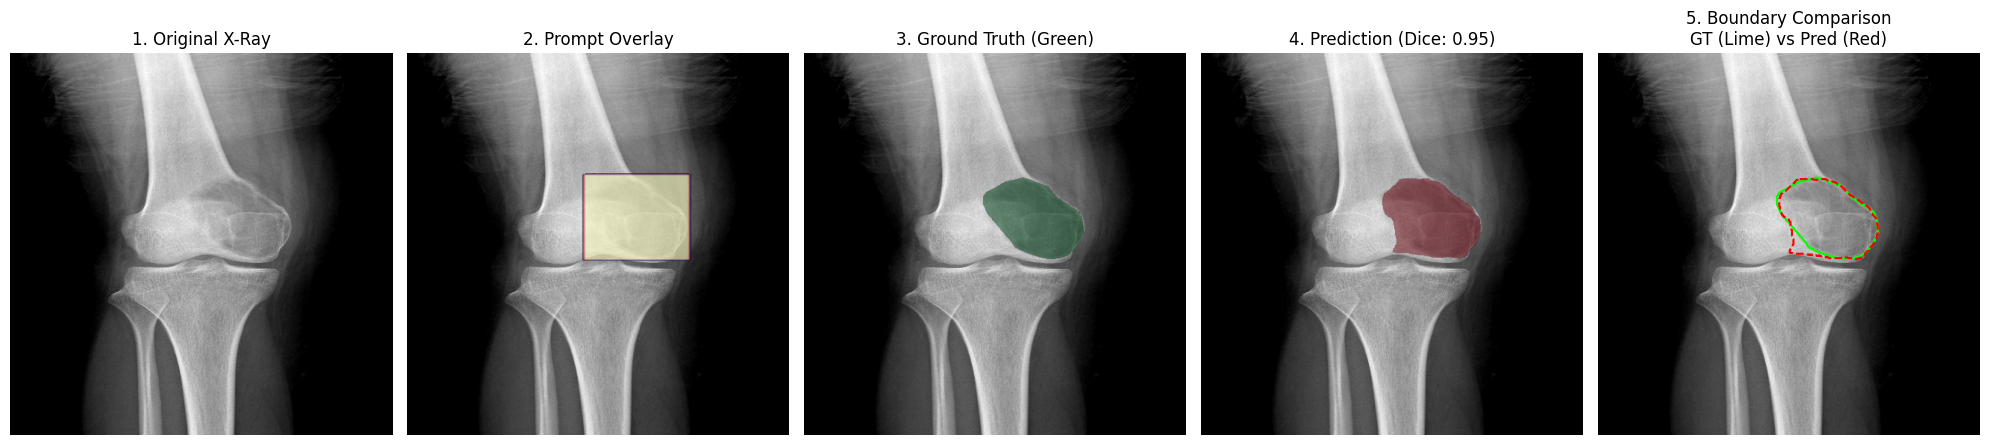

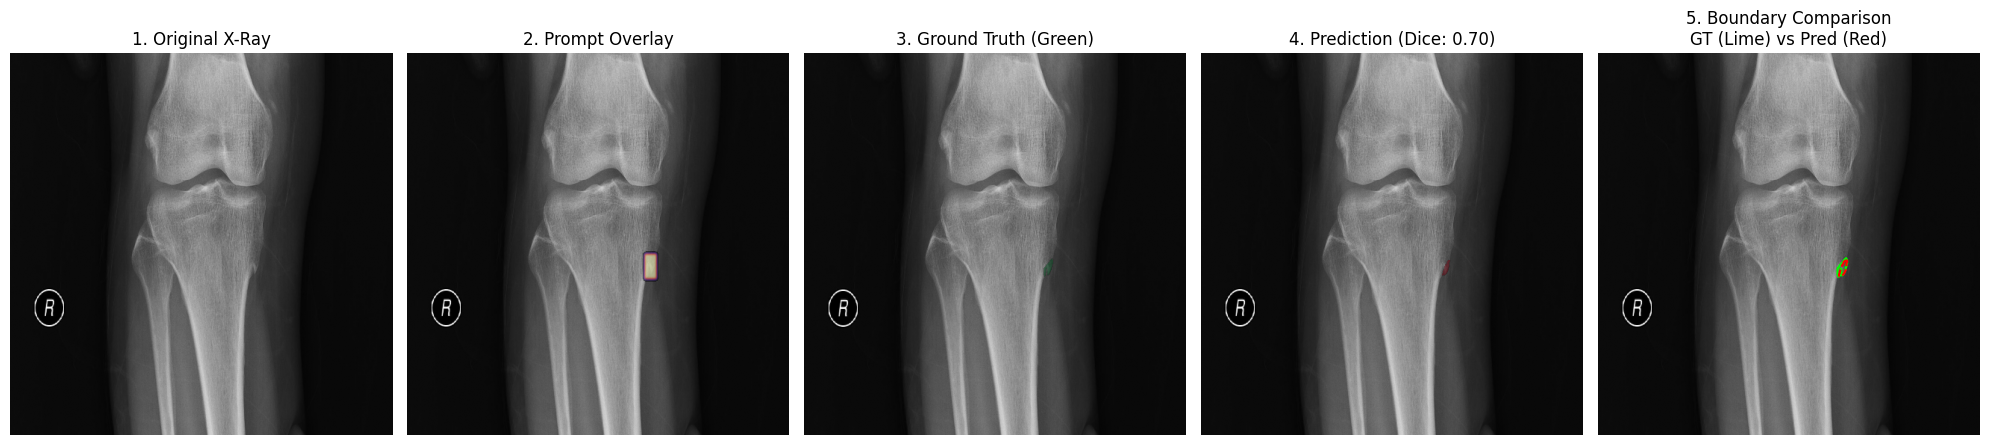

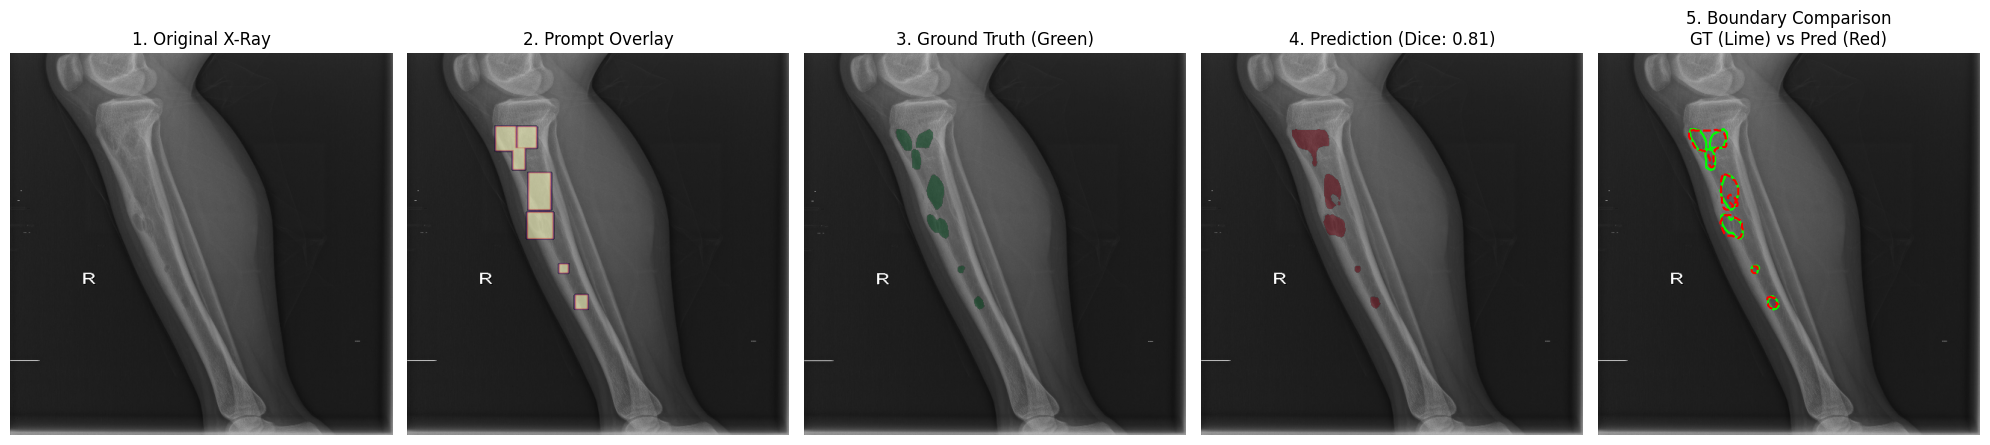


📊 KẾT QUẢ KIỂM THỬ: PROMPT-GUIDED MODEL (Kịch bản 2)
Mean Dice      : 0.8752
Mean IoU       : 0.7853
Mean Precision : 0.8636
Mean Recall    : 0.8998


In [ ]:
# =========================================================
# TEST PHASE: PROMPT-GUIDED ATTENTION U-NET (THESIS VERSION)
# =========================================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from dataset import BTXRD_Dataset
from models.networks.prompt_unet_2D import Prompt_Att_UNet_2D

# =========================================================
# CONFIG
# =========================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "checkpoints/att_unet_best.pth"
IMG_SIZE = 512 # Cập nhật đúng với kích thước lúc Train

# =========================================================
# LOAD MODEL
# =========================================================

model = Prompt_Att_UNet_2D(in_channels=1, n_classes=1).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

# =========================================================
# DATASET
# =========================================================

test_dataset = BTXRD_Dataset(
    image_dir="dataset_BTXRD/test/images",
    mask_dir="dataset_BTXRD/test/masks",
    json_dir="dataset_BTXRD/test/annotations", # Bắt buộc có dòng này
    img_size=IMG_SIZE,
    is_train=False
)

# Batch size 1 để tính chính xác cho từng ảnh và dễ dàng visualize
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# =========================================================
# VISUALIZATION CONTROL
# =========================================================
# 👉 Chọn các index bạn muốn in ra màn hình để cắt dán vào luận văn
SHOW_INDEX = [0, 5, 10]

# =========================================================
# METRICS TRACKING
# =========================================================

dice_scores = []
iou_scores = []
precision_scores = []
recall_scores = []

# =========================================================
# TEST LOOP (ORACLE MODE - HOÀN HẢO)
# =========================================================

with torch.no_grad():
    for idx, (images, masks, prompts) in enumerate(test_loader):

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        prompts = prompts.to(DEVICE)

        # Mô hình cải tiến nhận 2 inputs
        outputs = model(images, prompts)
        probs = torch.sigmoid(outputs)

        # -------------------------
        # BINARY PREDICTION
        # -------------------------
        preds = (probs > 0.5).float()

        # -------------------------
        # CHUẨN HÓA CÁC ĐỘ ĐO CHO TỪNG ẢNH
        # -------------------------
        tp = (preds * masks).sum().item()
        fp = (preds * (1 - masks)).sum().item()
        fn = ((1 - preds) * masks).sum().item()

        intersection = tp
        union = tp + fp + fn

        dice = (2.0 * intersection + 1e-5) / (preds.sum().item() + masks.sum().item() + 1e-5)
        iou = (intersection + 1e-5) / (union + 1e-5)
        precision = tp / (tp + fp + 1e-5)
        recall = tp / (tp + fn + 1e-5)

        dice_scores.append(dice)
        iou_scores.append(iou)
        precision_scores.append(precision)
        recall_scores.append(recall)

        # =====================================================
        # VISUALIZATION (OVERLAY CHUẨN PAPER IEEE)
        # =====================================================

        if idx in SHOW_INDEX:
            img = images[0, 0].cpu().numpy()
            prompt_map = prompts[0, 0].cpu().numpy()
            gt = masks[0, 0].cpu().numpy()
            pred = preds[0, 0].cpu().numpy()

            plt.figure(figsize=(20, 5)) # Mở rộng thêm chút cho thoáng

            # 1. ẢNH X-RAY GỐC
            plt.subplot(1, 5, 1)
            plt.imshow(img, cmap='gray')
            plt.title("1. Original X-Ray")
            plt.axis('off')

            # 2. X-RAY đè PROMPT (Heatmap màu lửa)
            plt.subplot(1, 5, 2)
            plt.imshow(img, cmap='gray')
            # Lọc bỏ nền đen, chỉ hiển thị vùng prompt có giá trị > 0.05
            masked_prompt = np.ma.masked_where(prompt_map < 0.05, prompt_map)
            plt.imshow(masked_prompt, cmap='magma', alpha=0.6)
            plt.title("2. Prompt Overlay")
            plt.axis('off')

            # 3. X-RAY đè GROUND TRUTH (Màu Xanh lá)
            plt.subplot(1, 5, 3)
            plt.imshow(img, cmap='gray')
            # Lọc bỏ nền đen của GT
            masked_gt = np.ma.masked_where(gt == 0, gt)
            plt.imshow(masked_gt, cmap='Greens', alpha=0.5, vmin=0, vmax=1)
            plt.title("3. Ground Truth (Green)")
            plt.axis('off')

            # 4. X-RAY đè PREDICTION (Màu Đỏ)
            plt.subplot(1, 5, 4)
            plt.imshow(img, cmap='gray')
            masked_pred = np.ma.masked_where(pred == 0, pred)
            plt.imshow(masked_pred, cmap='Reds', alpha=0.5, vmin=0, vmax=1)
            plt.title(f"4. Prediction (Dice: {dice:.2f})")
            plt.axis('off')

            # 5. SO SÁNH ĐƯỜNG BIÊN (Cực kỳ ăn điểm hội đồng)
            plt.subplot(1, 5, 5)
            plt.imshow(img, cmap='gray')

            # Vẽ nét đứt/đường viền (Contour) bao quanh khối U thay vì tô đặc
            if gt.max() > 0: # Đảm bảo có khối U mới vẽ
                plt.contour(gt, levels=[0.5], colors='lime', linewidths=1.5)
            if pred.max() > 0:
                plt.contour(pred, levels=[0.5], colors='red', linewidths=1.5, linestyles='dashed')

            plt.title("5. Boundary Comparison\nGT (Lime) vs Pred (Red)")
            plt.axis('off')

            plt.tight_layout()
            plt.show()

# =========================================================
# FINAL REPORT (FOR THESIS)
# =========================================================

print("\n" + "=" * 55)
print("📊 KẾT QUẢ KIỂM THỬ: PROMPT-GUIDED MODEL (Kịch bản 2)")
print("=" * 55)

print(f"Mean Dice      : {np.mean(dice_scores):.4f}")
print(f"Mean IoU       : {np.mean(iou_scores):.4f}")
print(f"Mean Precision : {np.mean(precision_scores):.4f}")
print(f"Mean Recall    : {np.mean(recall_scores):.4f}")

print("=" * 55)

**Download checkpoint về máy**

In [ ]:
# =========================================================
# DOWNLOAD CHECKPOINT _ LOG
# =========================================================

!zip -r results.zip checkpoints logs
from google.colab import files
files.download("results.zip")

  adding: checkpoints/ (stored 0%)
  adding: checkpoints/att_unet_best.pth (deflated 8%)
  adding: checkpoints/att_unet_last.pth (deflated 8%)
  adding: logs/ (stored 0%)
  adding: logs/training_baseline_20260508_201145.log (deflated 60%)
  adding: logs/training_baseline_20260508_201304.log (deflated 60%)
  adding: logs/training_baseline_20260508_202409.log (deflated 60%)
  adding: logs/training_baseline_20260508_132849.log (deflated 77%)
  adding: logs/training_baseline_20260508_202026.log (deflated 60%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>